In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [29]:
import pandas as pd
df = pd.read_csv('housing_data.csv')
print(df.shape)
df.head()

(2000, 8)


,SquareFeet,Bedrooms,Bathrooms,HouseAge,DistanceToCityCenter,GarageSpaces,Neighborhood,Price
0,2073,2,1.0,9,30.0,1,Suburban,74895432.08
1,1724,1,3.0,2,7.4,0,Rural / Outskirts,300000.00
2,2156,2,1.0,23,1.0,0,Rural / Outskirts,9846828.30
3,2638,1,1.5,27,30.0,0,Suburban,11553770.11
4,1671,3,2.5,3,3.4,0,City Center,11912909.38


In [38]:
print('Missing values in each column:')
print(df.isnull().sum())

# Fill any missing numerical values with their median
df = df.fillna(df.median(numeric_only=True))

Missing values in each column:
SquareFeet              0
Bedrooms                0
Bathrooms               0
HouseAge                0
DistanceToCityCenter    0
GarageSpaces            0
Neighborhood            0
Price                   0
dtype: int64


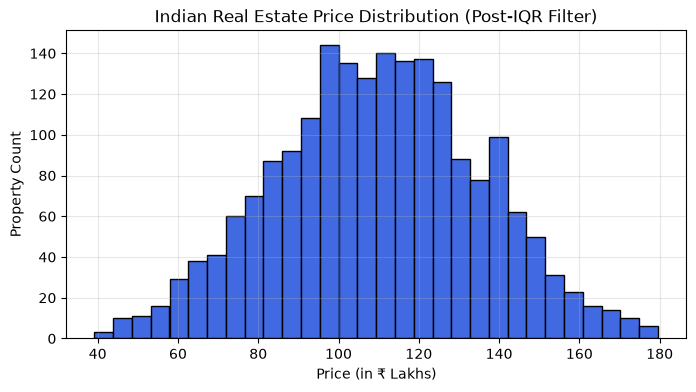

In [39]:
# Calculate IQR for the Price column
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)
 
# Keep only rows within the acceptable limits
initial_rows = len(df)
df_clean = df[(df['Price'] >= lower_limit) & (df['Price'] <= upper_limit)].copy()

# Quick plot to see clean price distribution
plt.figure(figsize=(8, 4))
plt.hist(df_clean['Price'] / 100000, bins=30, color='royalblue', edgecolor='black')
plt.title('Indian Real Estate Price Distribution (Post-IQR Filter)')
plt.xlabel('Price (in ₹ Lakhs)')
plt.ylabel('Property Count')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
# Separate Features (X) and Target (y)
X = df_clean.drop(columns=['Price'])
y = df_clean['Price']

# If TotalRooms exists from prior steps and is duplicate, remove it
if 'TotalRooms' in X.columns:
    X = X.drop(columns=['TotalRooms'])

# One-hot encode with drop_first=True to avoid dummy variable trap
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head(3)

,SquareFeet,Bedrooms,Bathrooms,HouseAge,DistanceToCityCenter,GarageSpaces,Neighborhood_Gated Society,Neighborhood_Rural / Outskirts,Neighborhood_Suburban
2,2156,2,1.0,23,1.0,0,0,1,0
3,2638,1,1.5,27,30.0,0,0,0,1
4,1671,3,2.5,3,3.4,0,0,0,0


In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add a constant column to calculate VIF correctly
X_vif = add_constant(X)

vif_table = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(X.columns))]
})

print('--- VIF Scores (Safe if < 10) ---')
print(vif_table.round(2))

--- VIF Scores (Safe if < 10) ---
                          Feature   VIF
0                      SquareFeet  1.00
1                        Bedrooms  1.00
2                       Bathrooms  1.00
3                        HouseAge  1.00
4            DistanceToCityCenter  1.00
5                    GarageSpaces  1.01
6      Neighborhood_Gated Society  1.45
7  Neighborhood_Rural / Outskirts  1.38
8           Neighborhood_Suburban  1.58


In [43]:
# 1. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale features so large numbers (like 3000 sq ft) don't overpower small numbers (like 3 bedrooms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=500.0)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Model': name,
        'R² Score (Accuracy)': f'{r2 * 100:.2f}%',
        'MAE (Avg Error)': format_inr(mae),
        'RMSE': format_inr(rmse)
    })

pd.DataFrame(results)

,Model,R² Score (Accuracy),MAE (Avg Error),RMSE
0,Linear Regression,99.45%,"₹ 144,368.38","₹ 184,664.49"
1,Ridge Regression,99.45%,"₹ 144,528.59","₹ 184,781.28"
2,Lasso Regression,99.45%,"₹ 144,552.31","₹ 184,781.60"


In [47]:
def format_inr(number):
    return f"₹ {number:,.2f}"

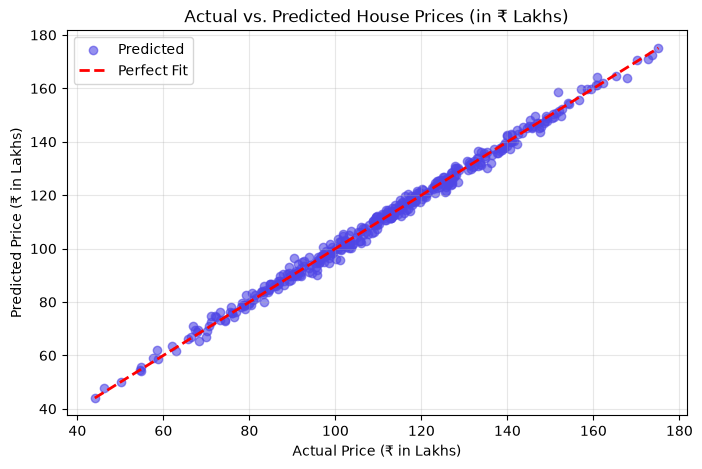

In [49]:
#Linear Regression predictions
best_model = models['Linear Regression']
y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(y_test / 100000, y_pred / 100000, color='#4f46e5', alpha=0.6, label='Predicted')
plt.plot([y_test.min() / 100000, y_test.max() / 100000], [y_test.min() / 100000, y_test.max() / 100000], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price (₹ in Lakhs)')
plt.ylabel('Predicted Price (₹ in Lakhs)')
plt.title('Actual vs. Predicted House Prices (in ₹ Lakhs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# Creating a single new house sample with identical column structure
sample_house = pd.DataFrame(0, index=[0], columns=X.columns)

# Enter your property values:
sample_house['SquareFeet'] = 1800
sample_house['Bedrooms'] = 3
sample_house['Bathrooms'] = 2.5
sample_house['HouseAge'] = 8
sample_house['DistanceToCityCenter'] = 6.0
sample_house['GarageSpaces'] = 2

# If neighborhood is Suburban, set Neighborhood_Suburban = 1
if 'Neighborhood_Suburban' in sample_house.columns:
    sample_house['Neighborhood_Suburban'] = 1

# Scale the new sample using the same scaler
sample_scaled = scaler.transform(sample_house)

# Predict price
predicted_price = best_model.predict(sample_scaled)[0]

print('ESTIMATED PROPERTY VALUATION:')
print(f'{format_inr(predicted_price)}')

ESTIMATED PROPERTY VALUATION:
₹ 10,860,041.66


In [28]:
import pickle
#import os

# Create model directory if it doesn't exist
#os.makedirs('model', exist_ok=True)
with open('linear_reg_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)